# Clohessy-Wiltshire relative motion: fundamentals, targeting, and relative orbit elements

This notebook lays the foundations that every proximity operations study in this package builds on. It starts from the linearized Hill-Clohessy-Wiltshire equations and shows how heyoka is used to integrate them, then looks at a couple of free motion cases that build intuition for drift and stability. From there it moves to impulsive maneuvers computed with two impulse targeting, and finally to relative orbit elements, six numbers that describe a relative orbit geometrically instead of as a raw state vector. The last section ties targeting and relative orbit elements together by designing and flying an insertion onto a drift free 2:1 ellipse, the same safety ellipse that the rendezvous notebook ends on.

The Hill equations describe the linearized relative motion of a deputy with respect to a chief on a circular orbit, valid when the separation is small compared to the orbital radius:

$$
\ddot{x} - 2n\dot{y} - 3n^2x = 0 \qquad
\ddot{y} + 2n\dot{x} = 0 \qquad
\ddot{z} + n^2z = 0
$$

where $n$ is the mean motion of the chief and $(x,y,z)$ is the relative position of the deputy in the chief's LVLH frame, $x$ radial, $y$ along-track, $z$ cross-track.

Being a linear system with constant coefficients, it admits a closed form solution, the Clohessy-Wiltshire solution, through a state transition matrix $\Phi$ such that

$$
\mathbf{X}(t) = \mathbf{\Phi}(t,t_0)\,\mathbf{X}(t_0), \qquad
\mathbf{X} = \begin{bmatrix} x & y & z & \dot{x} & \dot{y} & \dot{z} \end{bmatrix}^T
$$

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from ios_mission_planner.dynamics.relative.hill import hill_equations_symbolic
from ios_mission_planner.dynamics.relative.cw import cw_state_transition_matrix, cw_targeting
from ios_mission_planner.dynamics.relative.relative_orbit import (
    RelativeOrbit, relative_orbit_from_state, state_from_relative_orbit,
)
from ios_mission_planner.propagation.heyoka_propagator import propagate

mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})

COL_ANA = "#1f77b4"   # analytical / closed form
COL_NUM = "#d62728"   # numerical integration (heyoka)
COL_CHIEF = "#2ca02c"

## Setting up a chief orbit

The chief is placed on a circular low Earth orbit at 500 km altitude. Its mean motion $n$ sets the time scale of everything relative that follows.

In [2]:
mu_earth = 398600.4418  # km^3/s^2
alt = 500.0              # km
a = 6378.137 + alt       # km, orbital radius (circular orbit)
n = np.sqrt(mu_earth / a**3)  # rad/s, mean motion
T = 2 * np.pi / n             # s, orbital period

print(f"n = {n:.6e} rad/s")
print(f"T = {T:.1f} s  ({T/60:.2f} min)")

n = 1.106783e-03 rad/s
T = 5677.0 s  (94.62 min)


## Two ways to propagate the same equations

`cw_state_transition_matrix(t, n)` gives the closed form Clohessy-Wiltshire solution: evaluate it at each time step and multiply by the initial state. `propagate(...)` is the generic heyoka based propagator from the package: it integrates the Hill equations themselves, built by `hill_equations_symbolic()`, with the mean motion as a runtime parameter. The two functions below wrap each path so the case studies can call either one with the same signature.

In [3]:
def propagate_analytical(state0, t_eval, n):
    """Propagation using the CW state transition matrix, evaluated at each time step."""
    return np.array([cw_state_transition_matrix(t, n) @ state0 for t in t_eval])


def propagate_numerical(state0, t_eval, n):
    """Numerical propagation of the Hill equations, via heyoka's Taylor-adaptive integrator."""
    solution = propagate(hill_equations_symbolic(), state0, t_eval, pars=[n])
    return solution.y.T

## How heyoka is used here

heyoka is not handed a Python function to evaluate at every step, the way `scipy.integrate.solve_ivp` would be. It is handed the equations themselves, as symbolic expressions, and builds a specialised integrator from them. Three things are worth seeing once.

**A symbolic ODE system.** `hill_equations_symbolic()` returns a list of (variable, right hand side) pairs built with heyoka's expression objects. The mean motion $n$ is not a number baked into the expressions but a runtime parameter, printed below as `p0`, so the same compiled system serves any chief orbit.

In [4]:
import heyoka as hy

system = hill_equations_symbolic()
for state_var, rhs in system:
    print(f"d({state_var})/dt = {rhs}")

d(x)/dt = vx
d(y)/dt = vy
d(z)/dt = vz
d(vx)/dt = (((2.0000000000000000 * p0) * vy) + ((3.0000000000000000 * p0**2.0000000000000000) * x))
d(vy)/dt = ((-2.0000000000000000 * p0) * vx)
d(vz)/dt = (-p0**2.0000000000000000 * z)


**Taylor's method.** heyoka differentiates the equations symbolically, through automatic differentiation, and compiles, via LLVM, code that evaluates the Taylor series of the solution around the current state, up to some order. A step of size $h$ is then just evaluating that polynomial. Both the order and the step size are chosen automatically so that the truncation error of the series stays below a tolerance, which by default is the machine epsilon of a double, about $2.2\times10^{-16}$. That is why `propagate()` never asks for `rtol` or `atol`, and why the numerical solution below agrees with the analytical STM down to about $10^{-12}$ m.

In [5]:
x0 = 50.0
state0 = [x0, 0.0, 0.0, 0.0, -2 * n * x0, 0.0]

ta = hy.taylor_adaptive(system, state=state0, pars=[n])   # LLVM compilation happens here

print(f"truncation-error tolerance : {ta.tol:.3e}  (machine epsilon)")
print(f"Taylor series order        : {ta.order}")
print(f"orbital period             : {T:.1f} s")
print()
print("first adaptive steps:")
for i in range(6):
    outcome, h = ta.step()
    print(f"  step {i + 1}: h = {h:7.1f} s   ->  t = {ta.time:8.1f} s  ({ta.time / T:5.3f} orbits)")

truncation-error tolerance : 2.220e-16  (machine epsilon)
Taylor series order        : 20
orbital period             : 5677.0 s

first adaptive steps:
  step 1: h =   901.0 s   ->  t =    901.0 s  (0.159 orbits)
  step 2: h =   956.2 s   ->  t =   1857.2 s  (0.327 orbits)
  step 3: h =   966.5 s   ->  t =   2823.7 s  (0.497 orbits)
  step 4: h =   901.0 s   ->  t =   3724.7 s  (0.656 orbits)
  step 5: h =   954.4 s   ->  t =   4679.1 s  (0.824 orbits)
  step 6: h =   968.8 s   ->  t =   5648.0 s  (0.995 orbits)


With an order 20 series each step covers roughly a sixth of an orbit, far more than a fixed order Runge-Kutta scheme would need for the same accuracy.

**Reuse: state and parameters are just data.** The compiled integrator does not need to be rebuilt when $n$, the state, or the time change. Below, the same object, without recompiling, is pointed at a geostationary chief instead, and an impulsive burn is applied simply by editing the velocity entries of the state between two integrations. This is the mechanism every multi leg mission in this package relies on: a burn is "edit the state, keep integrating", and a mission profile is a sequence of such legs.

In [6]:
n_geo = 7.2921e-5   # rad/s, geostationary chief
ta.pars[:] = [n_geo]
ta.state[:] = [x0, 0.0, 0.0, 0.0, -2 * n_geo * x0, 0.0]
ta.time = 0.0

outcome, h = ta.step()
print(f"GEO chief: first step h = {h:.0f} s  ({h / (2 * np.pi / n_geo):.3f} of its orbit)")

# an impulsive burn is just an edit of the state between two integrations
ta.state[3] += 0.01          # 1 cm/s radial burn
print(f"after a 1 cm/s radial burn: state = {np.array2string(ta.state, precision=4, suppress_small=True)}")

GEO chief: first step h = 13675 s  (0.159 of its orbit)
after a 1 cm/s radial burn: state = [ 27.1328 -83.9955   0.       0.0069  -0.004    0.    ]


`propagate()` in the package is the convenient wrapper around exactly this: it builds the integrator, evaluates the solution on the requested time grid, and returns it in the same layout `solve_ivp` used. Building the integrator takes a few milliseconds for a system this small, so creating a fresh one per case, as the studies below do, is not a concern.

## A plotting routine for the case studies

For each case, four views are shown together: the three dimensional trajectory in the chief's LVLH frame, its projection onto the orbital plane, position and velocity against time, and the position error between the analytical and numerical solutions, as a check that the two methods agree.

In [7]:
def run_case(state0, n_periods, n_pts=800):
    t_eval = np.linspace(0, n_periods * T, n_pts)
    ana = propagate_analytical(state0, t_eval, n)
    num = propagate_numerical(state0, t_eval, n)
    err = np.linalg.norm(ana[:, :3] - num[:, :3], axis=1)
    return t_eval, ana, num, err


def plot_case(title, t_eval, ana, num, err, elev=25, azim=-50):
    t_p = t_eval / T
    x_a, y_a, z_a = ana[:, 0], ana[:, 1], ana[:, 2]
    x_n, y_n, z_n = num[:, 0], num[:, 1], num[:, 2]

    fig = plt.figure(figsize=(11, 8))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=0.99)
    gs = fig.add_gridspec(2, 3, height_ratios=[1.3, 1], hspace=0.4, wspace=0.32, top=0.90)

    ax3d = fig.add_subplot(gs[0, :2], projection="3d")
    ax3d.plot(x_a, y_a, z_a, color=COL_ANA, lw=2, label="CW analytical (STM)")
    ax3d.plot(x_n, y_n, z_n, color=COL_NUM, lw=1.2, ls="--", label="Numerical (Hill ODE)")
    ax3d.scatter([0], [0], [0], color=COL_CHIEF, s=60, marker="^", label="Chief", depthshade=False)
    ax3d.scatter([x_a[0]], [y_a[0]], [z_a[0]], color="k", s=35, marker="o", label="Deputy $t_0$", depthshade=False)
    ax3d.set_xlabel("x, radial [m]"); ax3d.set_ylabel("y, along-track [m]"); ax3d.set_zlabel("z, cross-track [m]")
    ax3d.set_title("3D relative trajectory (LVLH)", fontsize=10)
    ax3d.legend(loc="upper right", bbox_to_anchor=(1.32, 1.0), fontsize=8, framealpha=0.9)
    ax3d.view_init(elev=elev, azim=azim)

    ax_xy = fig.add_subplot(gs[0, 2])
    ax_xy.plot(y_a, x_a, color=COL_ANA, lw=2)
    ax_xy.plot(y_n, x_n, color=COL_NUM, lw=1.2, ls="--")
    ax_xy.scatter([0], [0], color=COL_CHIEF, s=60, marker="^", zorder=5)
    ax_xy.scatter([y_a[0]], [x_a[0]], color="k", s=30, zorder=5)
    ax_xy.set_xlabel("y, along-track [m]"); ax_xy.set_ylabel("x, radial [m]")
    ax_xy.set_title("In-plane projection", fontsize=10)
    ax_xy.set_aspect("equal", adjustable="datalim")

    ax_pos = fig.add_subplot(gs[1, 0])
    for lbl, a_, n_, c in zip(["x", "y", "z"], [x_a, y_a, z_a], [x_n, y_n, z_n],
                               ["#1f77b4", "#ff7f0e", "#2ca02c"]):
        ax_pos.plot(t_p, a_, color=c, lw=1.6, label=lbl)
        ax_pos.plot(t_p, n_, color=c, lw=1, ls="--")
    ax_pos.set_xlabel("time [orbital periods]"); ax_pos.set_ylabel("position [m]")
    ax_pos.set_title("Position vs. time"); ax_pos.legend(fontsize=8, ncol=3)

    ax_vel = fig.add_subplot(gs[1, 1])
    for lbl, a_, n_, c in zip(["vx", "vy", "vz"], [ana[:, 3], ana[:, 4], ana[:, 5]],
                               [num[:, 3], num[:, 4], num[:, 5]], ["#1f77b4", "#ff7f0e", "#2ca02c"]):
        ax_vel.plot(t_p, a_, color=c, lw=1.6, label=lbl)
        ax_vel.plot(t_p, n_, color=c, lw=1, ls="--")
    ax_vel.set_xlabel("time [orbital periods]"); ax_vel.set_ylabel("velocity [m/s]")
    ax_vel.set_title("Velocity vs. time"); ax_vel.legend(fontsize=8, ncol=3)

    ax_err = fig.add_subplot(gs[1, 2])
    ax_err.semilogy(t_p, np.clip(err, 1e-14, None), color="k", lw=1.4)
    ax_err.set_xlabel("time [orbital periods]"); ax_err.set_ylabel("|position error| [m]")
    ax_err.set_title("Analytical vs. numerical", fontsize=10)

    plt.show()
    print(f"max position error: {err.max():.3e} m")

## Free motion: drift and stability

Two things decide whether a relative orbit holds its shape or drifts away: whether the deputy ends up on an orbit with the same semi-major axis as the chief, and the phasing of any out-of-plane motion relative to the in-plane one. The two case studies below make both effects visible.

### Drift-free ellipse versus drift

A purely radial offset $x_0$ by itself is not a stable configuration. With zero relative velocity, the deputy ends up on a slightly different orbit than the chief, with a slightly different period, and the result is a secular drift along the track that grows linearly in time. Give it the along-track velocity $\dot y_0 = -2nx_0$ instead, and the deputy ends up on an orbit with the same energy as the chief: the relative motion is then a periodic 2:1 ellipse, twice as long along the track as it is radially, centred on the chief and repeated every orbital period without any further burn. This drift-free condition is the single most useful result of the whole linear theory, and it recurs throughout this package.

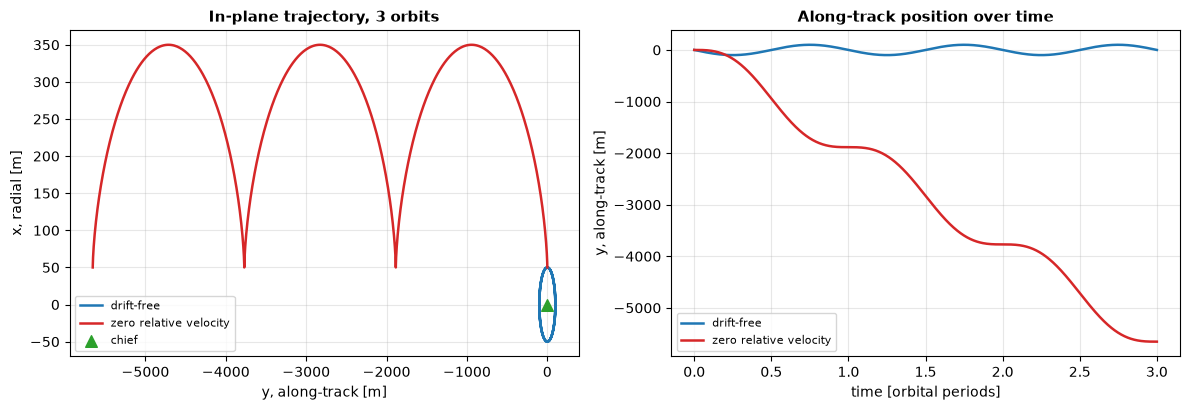

along-track drift after 3 orbits (zero relative velocity case): -5654.9 m


In [8]:
x0 = 50.0
state_free = [x0, 0.0, 0.0, 0.0, -2 * n * x0, 0.0]   # drift-free: y-dot0 = -2 n x0
state_drift = [x0, 0.0, 0.0, 0.0, 0.0, 0.0]            # same offset, zero relative velocity

t_eval = np.linspace(0, 3 * T, 1000)
free = propagate_numerical(state_free, t_eval, n)
drift = propagate_numerical(state_drift, t_eval, n)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.plot(free[:, 1], free[:, 0], color=COL_ANA, lw=1.8, label="drift-free")
ax.plot(drift[:, 1], drift[:, 0], color=COL_NUM, lw=1.8, label="zero relative velocity")
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=70, zorder=5, label="chief")
ax.set_xlabel("y, along-track [m]"); ax.set_ylabel("x, radial [m]")
ax.set_title("In-plane trajectory, 3 orbits")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(t_eval / T, free[:, 1], color=COL_ANA, lw=1.8, label="drift-free")
ax.plot(t_eval / T, drift[:, 1], color=COL_NUM, lw=1.8, label="zero relative velocity")
ax.set_xlabel("time [orbital periods]"); ax.set_ylabel("y, along-track [m]")
ax.set_title("Along-track position over time")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"along-track drift after 3 orbits (zero relative velocity case): {drift[-1, 1] - drift[0, 1]:.1f} m")

### Natural motion circumnavigation

Adding an out-of-plane oscillation at the same frequency $n$, with a matching amplitude $\dot z_0 = n z_0$, to the drift-free ellipse above produces a tilted 3D ellipse: the deputy circumnavigates the chief, periodically passing above, below, in front of, and behind it, without ever requiring propulsive corrections. This natural motion is the basis of passive inspection trajectories used in proximity operations.

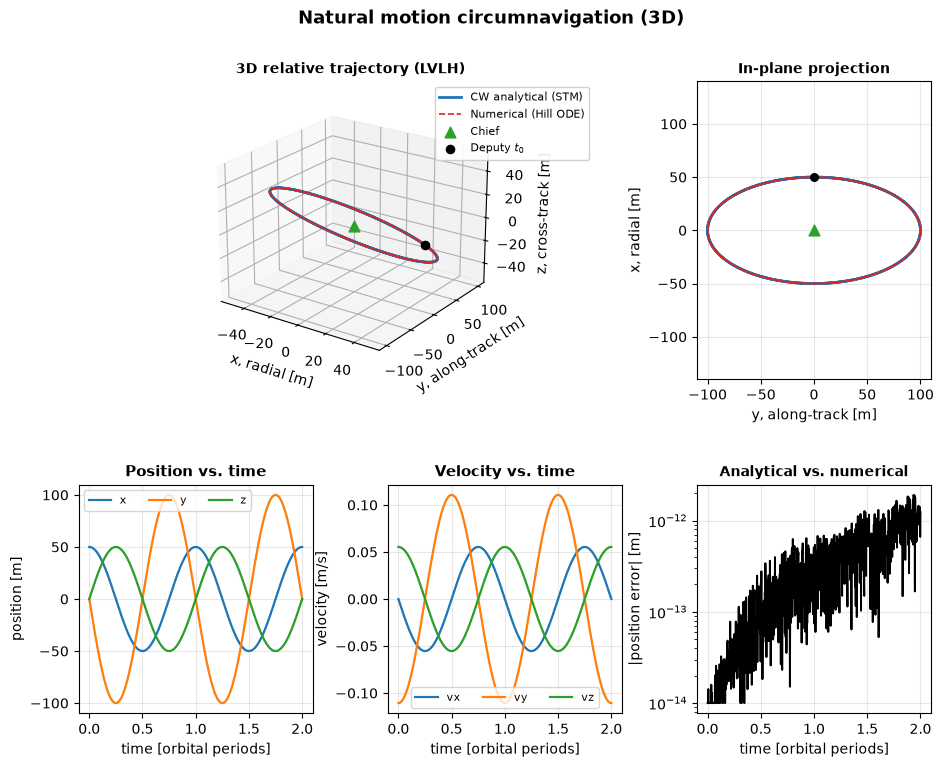

max position error: 1.911e-12 m


In [9]:
z0 = 50.0
zdot0 = z0 * n
state_nmc = [x0, 0.0, 0.0, 0.0, -2 * n * x0, zdot0]

t_eval, ana, num, err = run_case(state_nmc, n_periods=2)
plot_case("Natural motion circumnavigation (3D)", t_eval, ana, num, err, elev=22, azim=-55)

## Impulsive maneuvers: two-impulse targeting

The deputy is at $(\mathbf r_0, \mathbf v_0^-)$ and must be at $(\mathbf r_f, \mathbf v_f)$ after a time of flight $t$. With impulsive burns the trajectory in between is a free CW coast, so the whole problem is one linear algebra step on the state transition matrix. Splitting the STM into $3\times3$ blocks,

$$
\begin{bmatrix}\mathbf r(t)\\ \mathbf v(t)\end{bmatrix}
=
\begin{bmatrix}\Phi_{rr} & \Phi_{rv}\\ \Phi_{vr} & \Phi_{vv}\end{bmatrix}
\begin{bmatrix}\mathbf r_0\\ \mathbf v_0^+\end{bmatrix}
$$

where $\mathbf v_0^+ = \mathbf v_0^- + \Delta\mathbf v_1$ is the velocity right after the first burn. The position equation $\mathbf r_f = \Phi_{rr}\mathbf r_0 + \Phi_{rv}\mathbf v_0^+$ gives

$$
\mathbf v_0^+ = \Phi_{rv}^{-1}\left(\mathbf r_f - \Phi_{rr}\mathbf r_0\right),
\qquad \Delta\mathbf v_1 = \mathbf v_0^+ - \mathbf v_0^-
$$

Plugging $\mathbf v_0^+$ into the velocity equation gives the velocity the deputy actually has on arrival, $\mathbf v(t)^- = \Phi_{vr}\mathbf r_0 + \Phi_{vv}\mathbf v_0^+$, and the second burn closes the gap to the desired velocity:

$$
\Delta\mathbf v_2 = \mathbf v_f - \mathbf v(t)^-
$$

Everything hinges on inverting $\Phi_{rv}$, whose in-plane determinant is

$$
\det\Phi_{rv}^{\,\text{in-plane}} = \frac{8 - 8\cos nt - 3\,nt\,\sin nt}{n^2}
$$

This vanishes at a full orbit and at a few other special times of flight. There $\Phi_{rv}$ loses rank, and either the target is unreachable by a free coast and the required $\Delta v$ diverges, or the target happens to be reachable in infinitely many ways and the solver returns just one of them, not necessarily the cheapest. A singular time of flight is always worth checking for.

The example below is a V-bar hop from a hold point at $y=-1000$ m to one at $y=-200$ m, both at rest, and looks at how the cost depends on the chosen time of flight.

<>:30: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:30: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\d'
C:\Users\giova\AppData\Local\Temp\ipykernel_9948\2076836003.py:30: SyntaxWarning: invalid escape sequence '\D'
  axes[0].plot(f, dv[:, 0], color=COL_NUM, lw=1, ls="--", label="$|\Delta v_1|$")
C:\Users\giova\AppData\Local\Temp\ipykernel_9948\2076836003.py:31: SyntaxWarning: invalid escape sequence '\D'
  axes[0].plot(f, dv[:, 1], color=COL_ANA, lw=1, ls=":", label="$|\Delta v_2|$")
C:\Users\giova\AppData\Local\Temp\ipykernel_9948\2076836003.py:43: SyntaxWarning: invalid escape sequence '\d'
  axes[1].set_ylabel("$n^2 \det\Phi_{rv}$ (in-plane)")


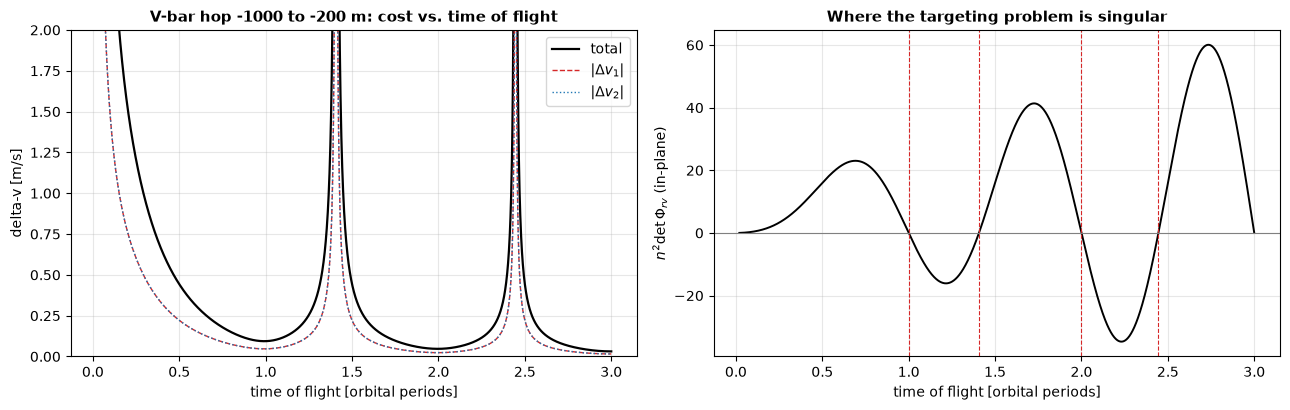

singular times of flight [orbital periods]: [1.    1.406 1.999 2.445]


In [10]:
r0 = np.array([0.0, -1000.0, 0.0])
v0 = np.zeros(3)
rf = np.array([0.0, -200.0, 0.0])
vf = np.zeros(3)


def dv_vs_tof(r0, v0, rf, vf, t_over_p):
    """|dv1|, |dv2|, total for each time of flight (in orbital periods). NaN where singular."""
    out = np.full((len(t_over_p), 3), np.nan)
    for i, f in enumerate(t_over_p):
        try:
            dv1, dv2 = cw_targeting(r0, v0, rf, vf, f * T, n)
        except np.linalg.LinAlgError:
            continue
        out[i, :2] = np.linalg.norm(dv1), np.linalg.norm(dv2)
    out[:, 2] = out[:, 0] + out[:, 1]
    return out


f = np.linspace(0.02, 3.0, 3000)
dv = dv_vs_tof(r0, v0, rf, vf, f)

u = 2 * np.pi * f
det_in_plane = (8 - 8 * np.cos(u) - 3 * u * np.sin(u)) / n**2
singular_at = f[:-1][np.sign(det_in_plane[:-1]) != np.sign(det_in_plane[1:])]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(f, dv[:, 2], color="k", lw=1.6, label="total")
axes[0].plot(f, dv[:, 0], color=COL_NUM, lw=1, ls="--", label="$|\Delta v_1|$")
axes[0].plot(f, dv[:, 1], color=COL_ANA, lw=1, ls=":", label="$|\Delta v_2|$")
axes[0].set_ylim(0, 2.0)
axes[0].set_xlabel("time of flight [orbital periods]")
axes[0].set_ylabel("delta-v [m/s]")
axes[0].set_title("V-bar hop -1000 to -200 m: cost vs. time of flight")
axes[0].legend()

axes[1].plot(f, det_in_plane * n**2, color="k", lw=1.4)
axes[1].axhline(0, color="gray", lw=0.8)
for s in singular_at:
    axes[1].axvline(s, color=COL_NUM, lw=0.8, ls="--")
axes[1].set_xlabel("time of flight [orbital periods]")
axes[1].set_ylabel("$n^2 \det\Phi_{rv}$ (in-plane)")
axes[1].set_title("Where the targeting problem is singular")

plt.tight_layout()
plt.show()

print("singular times of flight [orbital periods]:", np.round(singular_at, 3))

Fast hops are expensive, and the cost is not monotonic: beyond the steep initial rise it oscillates, with cheap windows sitting between the singular spikes, so a longer flight is not automatically a cheaper one. The time of flight is therefore a real design trade-off between propellant and mission time. The dashed lines on the right mark where $\det\Phi_{rv}=0$: the cost diverges at most of them, except at exactly one and two orbits, where this particular hop is still consistent (a free coast on a purely along-track configuration returns to $x=0$ after a full orbit) but the solution is not unique, so those points should not be trusted blindly.

The helper `fly` below applies a list of impulses and coasts with heyoka, so the result below is checked against the true Hill equations, independently of the STM used to compute the burns.

time of flight : 71.0 min (0.75 orbits)
dv1 = [-0.07999 -0.04    -0.     ] m/s   |dv1| = 0.08944 m/s
dv2 = [-0.07999  0.04     0.     ] m/s   |dv2| = 0.08944 m/s
total dv = 0.17887 m/s
arrival position error (heyoka vs. target): 1.14e-13 m


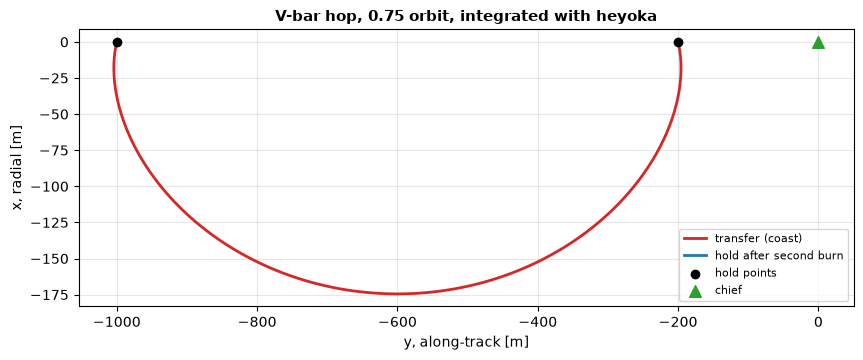

In [11]:
def fly(state0, plan, n, pts=400):
    """
    Integrate a sequence of (impulse, coast duration) pairs with heyoka.

    Each impulse dv is added to the velocity at the start of its leg, then the
    deputy coasts for the given duration. Returns time, states [n_samples, 6],
    and the state right after each impulse.
    """
    state = np.array(state0, dtype=float)
    t_start = 0.0
    times, states, after_burn = [], [], []

    for dv, duration in plan:
        state[3:] += dv
        after_burn.append(state.copy())

        t_eval = np.linspace(0.0, duration, pts)
        leg = propagate(hill_equations_symbolic(), state, t_eval, pars=[n])

        times.append(t_start + t_eval)
        states.append(leg.y.T)
        state = leg.y[:, -1].copy()
        t_start += duration

    return np.concatenate(times), np.vstack(states), after_burn


T_hop = 0.75 * T
dv1, dv2 = cw_targeting(r0, v0, rf, vf, T_hop, n)

t, y, after_burn = fly(np.concatenate([r0, v0]), [(dv1, T_hop), (dv2, T)], n)
pts = 400   # samples per leg, as in fly()

print(f"time of flight : {T_hop / 60:.1f} min ({T_hop / T:.2f} orbits)")
print(f"dv1 = {np.array2string(dv1, precision=5, suppress_small=True)} m/s   |dv1| = {np.linalg.norm(dv1):.5f} m/s")
print(f"dv2 = {np.array2string(dv2, precision=5, suppress_small=True)} m/s   |dv2| = {np.linalg.norm(dv2):.5f} m/s")
print(f"total dv = {np.linalg.norm(dv1) + np.linalg.norm(dv2):.5f} m/s")
print(f"arrival position error (heyoka vs. target): {np.linalg.norm(y[pts - 1, :3] - rf):.2e} m")

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(y[:pts, 1], y[:pts, 0], color=COL_NUM, lw=2, label="transfer (coast)")
ax.plot(y[pts:, 1], y[pts:, 0], color=COL_ANA, lw=2, label="hold after second burn")
ax.scatter([r0[1], rf[1]], [r0[0], rf[0]], color="k", zorder=5, label="hold points")
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=70, zorder=5, label="chief")
ax.set_xlabel("y, along-track [m]"); ax.set_ylabel("x, radial [m]")
ax.set_title("V-bar hop, 0.75 orbit, integrated with heyoka")
ax.legend(fontsize=8)
plt.show()

The transfer bows out radially and comes back: a rest-to-rest V-bar hop is never a straight line in the CW frame, because along-track motion couples to radial motion through the Coriolis-like terms $2n\dot y$ and $-2n\dot x$.

## Relative orbit elements

Grouping the terms of the closed-form CW solution by how they behave in time, a constant, a term growing linearly, and terms oscillating at the orbital frequency $n$, the in-plane and out-of-plane motion read (see also Analytical Mechanics of Space Systems, Fourth Edition, page 781):

$$
\begin{aligned}
x(t) &= x_{off} + \rho\cos(nt+\alpha)\\
y(t) &= y_c - \tfrac{3}{2}\,n\,x_{off}\,t - 2\rho\sin(nt+\alpha)\\
z(t) &= \rho_z\cos(nt+\beta)
\end{aligned}
$$

That is six numbers, $(x_{off}, y_c, \rho, \alpha, \rho_z, \beta)$, carrying exactly the same information as the six components of the state, but written in the language mission constraints are actually expressed in.

$\rho$ is the size of the in-plane ellipse: its radial semi-axis, with the along-track semi-axis always twice as large. This is the one number that answers "how big is the relative orbit".

$\alpha$ is the in-plane phase at $t=0$: where on the ellipse the deputy currently sits, not how big the ellipse is. Two deputies on ellipses of the same size but different $\alpha$ trace the same shape without ever being at the same place at the same time.

$x_{off}$ is the radial position of the ellipse's center, and it is the only source of secular drift: it is directly tied to the difference in semi-major axis, hence orbital energy, between deputy and chief, and the center slides along-track at $-\tfrac32 n\,x_{off}$. Setting $x_{off}=0$ is exactly the drift-free condition seen above, $\dot y_0 = -2nx_0$, read geometrically instead of as a velocity formula.

$y_c$ is where that center sits along the track at $t=0$. For a drift-free orbit ($x_{off}=0$) it is simply the along-track offset of the whole ellipse from the chief, the natural way to describe a hold point that is not exactly on top of the chief.

$\rho_z$ and $\beta$ play the same role out of plane that $\rho$ and $\alpha$ play in plane: $\rho_z$ is the amplitude of the cross-track oscillation, $\beta$ is its phase. When $\rho_z$ and the in-plane motion share the same frequency $n$ and are phased correctly, as in the natural motion circumnavigation above, the two combine into a single tilted 3D ellipse.

`relative_orbit_from_state` and `state_from_relative_orbit` convert between a raw state and this description, in both directions, without loss. The two orbits below, one drift-free and one drifting, are shown both as propagated by heyoka (solid) and by the closed-form description above (dashed), to check that the two really describe the same motion.

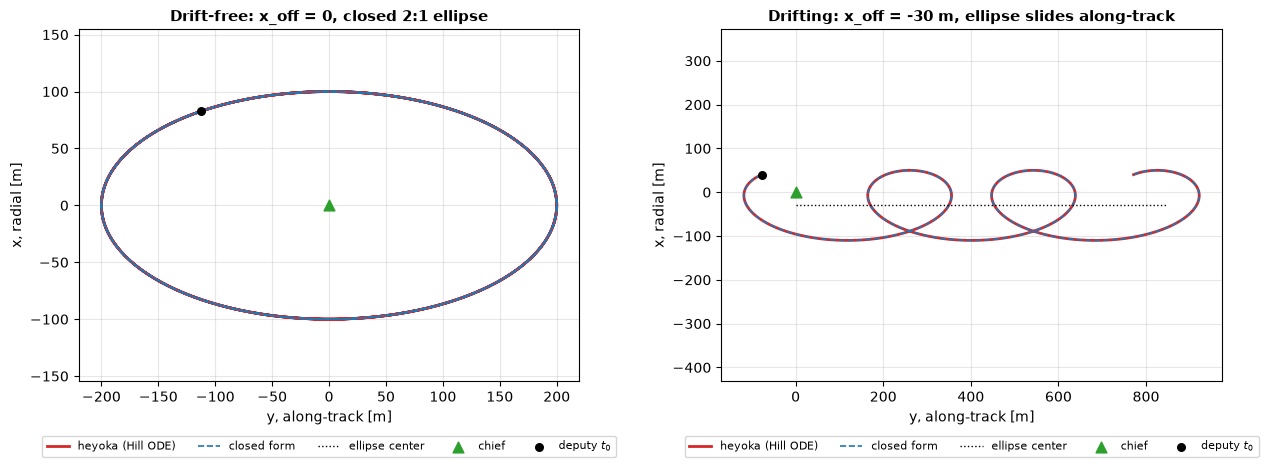

max |heyoka - closed form|, drift-free: 1.79e-12 m
max |heyoka - closed form|, drifting  : 1.02e-12 m
drift rate of the second orbit: 0.0498 m/s = 282.7 m per orbit


In [12]:
def orbit_position(orbit, t, n):
    """Position [x, y, z] from the closed-form relative-orbit description."""
    x = orbit.x_off + orbit.rho * np.cos(n * t + orbit.alpha)
    y = orbit.y_c + orbit.drift_rate(n) * t - 2.0 * orbit.rho * np.sin(n * t + orbit.alpha)
    z = orbit.rho_z * np.cos(n * t + orbit.beta)
    return np.array([x, y, z])


def plot_relative_orbit(ax, orbit, n_periods, title):
    t = np.linspace(0, n_periods * T, 800)
    state0 = state_from_relative_orbit(orbit, n)
    numerical = propagate(hill_equations_symbolic(), state0, t, pars=[n]).y
    analytic = orbit_position(orbit, t, n)

    ax.plot(numerical[1], numerical[0], color=COL_NUM, lw=2, label="heyoka (Hill ODE)")
    ax.plot(analytic[1], analytic[0], color=COL_ANA, lw=1.2, ls="--", label="closed form")
    y_center = orbit.y_c + orbit.drift_rate(n) * t
    ax.plot(y_center, np.full_like(t, orbit.x_off), color="k", lw=1, ls=":", label="ellipse center")
    ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=60, zorder=5, label="chief")
    ax.scatter([numerical[1, 0]], [numerical[0, 0]], color="k", s=30, zorder=5, label="deputy $t_0$")
    ax.set_xlabel("y, along-track [m]")
    ax.set_ylabel("x, radial [m]")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=5)

    return np.max(np.abs(numerical[:3] - analytic))


orbit_free = RelativeOrbit(x_off=0.0, y_c=0.0, rho=100.0, alpha=0.6)
orbit_drift = RelativeOrbit(x_off=-30.0, y_c=0.0, rho=80.0, alpha=0.5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
err_free = plot_relative_orbit(axes[0], orbit_free, 3, "Drift-free: x_off = 0, closed 2:1 ellipse")
err_drift = plot_relative_orbit(axes[1], orbit_drift, 3, "Drifting: x_off = -30 m, ellipse slides along-track")
plt.tight_layout()
plt.show()

print(f"max |heyoka - closed form|, drift-free: {err_free:.2e} m")
print(f"max |heyoka - closed form|, drifting  : {err_drift:.2e} m")
print(f"drift rate of the second orbit: {orbit_drift.drift_rate(n):.4f} m/s "
      f"= {orbit_drift.drift_rate(n) * T:.1f} m per orbit")

The conversion is invertible: a raw state goes to elements and back without loss, as it must since it is just a change of coordinates on the same six-dimensional space.

In [13]:
state_drift = state_from_relative_orbit(orbit_drift, n)
recovered = relative_orbit_from_state(state_drift, n)

print("state (x, y, z, vx, vy, vz):")
print(" ", np.array2string(state_drift, precision=5, suppress_small=True))
print()
print(f"{'element':8s} {'original':>12s} {'recovered':>12s}")
for name in ["x_off", "y_c", "rho", "alpha", "rho_z", "beta"]:
    print(f"{name:8s} {getattr(orbit_drift, name):12.6f} {getattr(recovered, name):12.6f}")

state (x, y, z, vx, vy, vz):
  [ 40.2066  -76.70809   0.       -0.04245  -0.1056   -0.     ]

element      original    recovered
x_off      -30.000000   -30.000000
y_c          0.000000     0.000000
rho         80.000000    80.000000
alpha        0.500000     0.500000
rho_z        0.000000     0.000000
beta         0.000000     0.000000


### A propagation starting directly from relative orbit elements

To close the loop, here is a relative orbit built from elements chosen directly, rather than from a raw state: a $\rho=70$ m ellipse, started at phase $\alpha=0$, with an out-of-plane amplitude $\rho_z=40$ m phased so that it combines with the in-plane ellipse into a tilted 3D path, the same construction as the natural motion circumnavigation earlier, but now designed top-down from the geometry instead of bottom-up from a velocity formula. `state_from_relative_orbit` turns it into a state, and from there it is an ordinary heyoka propagation.

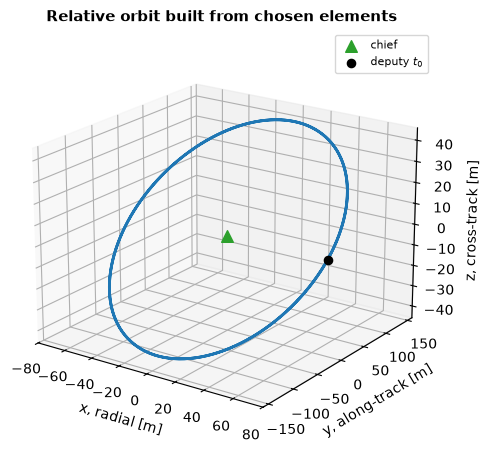

rho = 70.0 m, rho_z = 40.0 m, drift = -0.0e+00 m/s


In [14]:
orbit_nmc = RelativeOrbit(x_off=0.0, y_c=0.0, rho=70.0, alpha=0.0, rho_z=40.0, beta=np.pi / 2)
state_nmc_roe = state_from_relative_orbit(orbit_nmc, n)

t_eval = np.linspace(0, 2 * T, 800)
traj = propagate_numerical(state_nmc_roe, t_eval, n)

fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(projection="3d")
ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=COL_ANA, lw=2)
ax.scatter([0], [0], [0], color=COL_CHIEF, s=70, marker="^", label="chief", depthshade=False)
ax.scatter([traj[0, 0]], [traj[0, 1]], [traj[0, 2]], color="k", s=35, label="deputy $t_0$", depthshade=False)
ax.set_xlabel("x, radial [m]"); ax.set_ylabel("y, along-track [m]"); ax.set_zlabel("z, cross-track [m]")
ax.set_title("Relative orbit built from chosen elements")
ax.legend(fontsize=8)
ax.view_init(elev=20, azim=-55)
plt.show()

print(f"rho = {orbit_nmc.rho} m, rho_z = {orbit_nmc.rho_z} m, drift = {orbit_nmc.drift_rate(n):.1e} m/s")

## Putting it together: inserting onto a 2:1 safety ellipse

The two tools above combine directly: targeting can aim not just at a point but at a full relative orbit state, so a deputy can be inserted onto a chosen 2:1 ellipse exactly as it was aimed at the V-bar hold point earlier. If the arrival state satisfies the drift-free condition, the deputy stays on that ellipse for free, forever, within the linear model: no burn is needed to hold it, and if the deputy stops responding it keeps circling the chief instead of drifting into it. This is the passively safe parking orbit that the safety layer of the project will build on.

The target below is an ellipse with $\rho=100$ m, arriving at the point $x=0,\ y=-2\rho$, which is phase $\alpha=\pi/2$. The targeting call is the same `cw_targeting` used for the V-bar hop, only with a non-zero arrival velocity; the first burn comes out identical to the hop above, since it depends only on the positions and the time of flight, and changing the arrival velocity only changes the second burn.

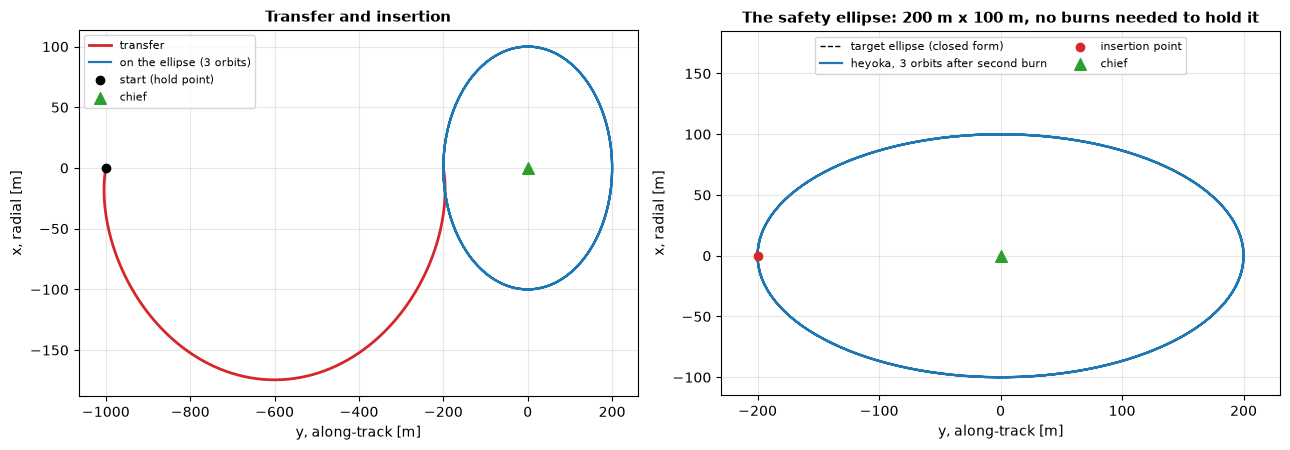

dv1 = [-0.07999 -0.04    -0.     ] m/s   |dv1| = 0.08944 m/s
dv2 = [-0.19067  0.04    -0.     ] m/s   |dv2| = 0.19482 m/s
total dv = 0.28426 m/s

relative orbit right after the second burn:
  x_off = 1.82e-13 m   (0 = no drift)
  drift = -3.02e-16 m/s
  rho   = 100.0000 m   (target 100.0)
  y_c   = 1.42e-13 m

arrival position error (heyoka vs. target) : 1.14e-13 m


In [15]:
rho_f = 100.0
target_orbit = RelativeOrbit(x_off=0.0, y_c=0.0, rho=rho_f, alpha=np.pi / 2)
state_arrival = state_from_relative_orbit(target_orbit, n)

T_ins = 0.75 * T
dv1, dv2 = cw_targeting(r0, v0, state_arrival[:3], state_arrival[3:], T_ins, n)

n_ellipse_orbits = 3
t, y, after_burn = fly(np.concatenate([r0, v0]), [(dv1, T_ins), (dv2, n_ellipse_orbits * T)], n)
pts = 400

phi = np.linspace(0, 2 * np.pi, 400)
ellipse_x = target_orbit.rho * np.cos(phi)
ellipse_y = -2 * target_orbit.rho * np.sin(phi)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ax.plot(y[:pts, 1], y[:pts, 0], color=COL_NUM, lw=2, label="transfer")
ax.plot(y[pts:, 1], y[pts:, 0], color=COL_ANA, lw=1.6, label="on the ellipse (3 orbits)")
ax.scatter([r0[1]], [r0[0]], color="k", zorder=5, label="start (hold point)")
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=70, zorder=5, label="chief")
ax.set_xlabel("y, along-track [m]"); ax.set_ylabel("x, radial [m]")
ax.set_title("Transfer and insertion")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(ellipse_y, ellipse_x, color="k", lw=1, ls="--", label="target ellipse (closed form)")
ax.plot(y[pts:, 1], y[pts:, 0], color=COL_ANA, lw=1.6, label="heyoka, 3 orbits after second burn")
ax.scatter([state_arrival[1]], [state_arrival[0]], color=COL_NUM, zorder=5, label="insertion point")
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=70, zorder=5, label="chief")
ax.set_xlabel("y, along-track [m]"); ax.set_ylabel("x, radial [m]")
ax.set_title("The safety ellipse: 200 m x 100 m, no burns needed to hold it")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-230, 230)
ax.set_ylim(-115, 185)
ax.legend(fontsize=8, loc="upper center", ncol=2)

plt.tight_layout()
plt.show()

after = relative_orbit_from_state(after_burn[1], n)
print(f"dv1 = {np.array2string(dv1, precision=5, suppress_small=True)} m/s   |dv1| = {np.linalg.norm(dv1):.5f} m/s")
print(f"dv2 = {np.array2string(dv2, precision=5, suppress_small=True)} m/s   |dv2| = {np.linalg.norm(dv2):.5f} m/s")
print(f"total dv = {np.linalg.norm(dv1) + np.linalg.norm(dv2):.5f} m/s")
print()
print("relative orbit right after the second burn:")
print(f"  x_off = {after.x_off:.2e} m   (0 = no drift)")
print(f"  drift = {after.drift_rate(n):.2e} m/s")
print(f"  rho   = {after.rho:.4f} m   (target {rho_f})")
print(f"  y_c   = {after.y_c:.2e} m")
print()
print(f"arrival position error (heyoka vs. target) : {np.linalg.norm(y[pts - 1, :3] - state_arrival[:3]):.2e} m")

## Summary

The drift-free condition, $\dot y_0 = -2nx_0$ or equivalently $x_{off}=0$, is the single idea that separates a relative orbit that holds its shape from one that drifts away, and it shows up identically whether read off a velocity, off the relative orbit elements, or off a targeting result. Two-impulse targeting turns "go from here to there in this much time" into one linear solve on the state transition matrix, with a cost that depends strongly, and non-monotonically, on the chosen time of flight. Relative orbit elements turn a six-number state into six numbers with direct physical meaning: how big the ellipse is, where the deputy sits on it, whether it drifts and how fast, where its center is along the track, and the amplitude and phase of any out-of-plane motion. Put together, they design and verify the insertion onto a 2:1 safety ellipse, the passively safe parking orbit this package keeps coming back to, all the way down to numerical noise against the true Hill equations.

The rendezvous notebook chains these pieces into a full approach: a phasing leg closes the along-track gap from a parking orbit, a far-range targeting burn pair brings the deputy into the chief's neighbourhood, and the insertion shown here puts it on the safety ellipse, all flown with nonlinear two-body dynamics instead of the linear model used to design it. Downstream, the ellipse geometry is exactly what the safety layer's keep-out and passive-abort analysis will constrain, and every delta-v computed here is a line item in the propellant budget of the end-to-end layer.